## 不動産物件の価格推定

2025年度のデータをダウンロードしてモデルを作成

https://www.reinfolib.mlit.go.jp/realEstatePrices/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("/content/Tokyo_20251_20254.csv", encoding="cp932")

In [3]:
df.columns

Index(['種類', '価格情報区分', '地域', '市区町村コード', '都道府県名', '市区町村名', '地区名', '最寄駅：名称',
       '最寄駅：距離（分）', '取引価格（総額）', '坪単価', '面積（㎡）', '取引価格（㎡単価）', '土地の形状', '間口',
       '延床面積（㎡）', '建築年', '建物の構造', '用途', '今後の利用目的', '前面道路：方位', '前面道路：種類',
       '前面道路：幅員（ｍ）', '都市計画', '建ぺい率（％）', '容積率（％）', '取引時期', '取引の事情等'],
      dtype='object')

In [4]:
df.shape

(20970, 28)

## 使用する変数の状況を確認し、前処理

In [5]:
df["建物の構造"].value_counts()

,count
建物の構造,
木造,14967
鉄骨造,768
ＲＣ,731
軽量鉄骨造,606
ＳＲＣ,74
ＲＣ、木造,37
鉄骨造、木造,18
ブロック造,6
ＲＣ、鉄骨造,4


In [6]:
df["前面道路：幅員（ｍ）"].isnull().sum()

np.int64(2957)

In [7]:
columns = [
    "取引価格（総額）",
    "地域",
    "市区町村名",
    "最寄駅：距離（分）",
    "面積（㎡）",
    "建築年",
    "前面道路：幅員（ｍ）"
]
df[columns]

,取引価格（総額）,地域,市区町村名,最寄駅：距離（分）,面積（㎡）,建築年,前面道路：幅員（ｍ）
0,340000000,商業地,千代田区,0,50,1954年,27.0
1,640000000,商業地,千代田区,6,180,NaN,6.0
2,780000000,商業地,千代田区,3,170,1982年,11.0
3,500000000,商業地,千代田区,5,105,NaN,8.0
4,1600000000,商業地,千代田区,3,185,1996年,11.0
...,...,...,...,...,...,...,...
20965,10000000,住宅地,八丈町,NaN,200,2000年,3.0
20966,5000000,商業地,八丈町,NaN,310,NaN,13.0
20967,550000,住宅地,八丈町,NaN,155,NaN,6.6
20968,4000000,住宅地,八丈町,NaN,890,1982年,5.5


In [8]:
# 0～5分、5～10分、10～20分、20～30分
df["最寄駅：距離（分）"].value_counts().sort_index()

,count
最寄駅：距離（分）,
0,9
1,116
10,3343
11,633
12,398
13,428
14,526
15,3174
16,336


In [9]:
from_station = df["最寄駅：距離（分）"].str.replace(r"^[01234]$", "0〜4分", regex=True)\
        .str.replace(r"^[56789]$$", "5〜9分", regex=True)\
        .str.replace(r"^1\d$", "10〜19分", regex=True)\
        .str.replace(r"^2\d$", "20〜29分", regex=True)
from_station = from_station.fillna("2H～")

In [10]:
# 島は除外、西多摩は統合
df["市区町村名"].value_counts()

,count
市区町村名,
練馬区,1434
世田谷区,1300
八王子市,1225
足立区,1142
杉並区,1041
大田区,1021
町田市,983
江戸川区,940
葛飾区,750


In [11]:
city = df["市区町村名"].str.replace(r"^西多摩郡.+", "西多摩郡", regex=True)\
                .str.replace(r".+[村町]$", "離島", regex=True)

In [12]:
df["建築年"].str.extract(r"(?P<建築年>\d+)年?").astype(float)

,建築年
0,1954.0
1,NaN
2,1982.0
3,NaN
4,1996.0
...,...
20965,2000.0
20966,NaN
20967,NaN
20968,1982.0


<Axes: ylabel='Frequency'>

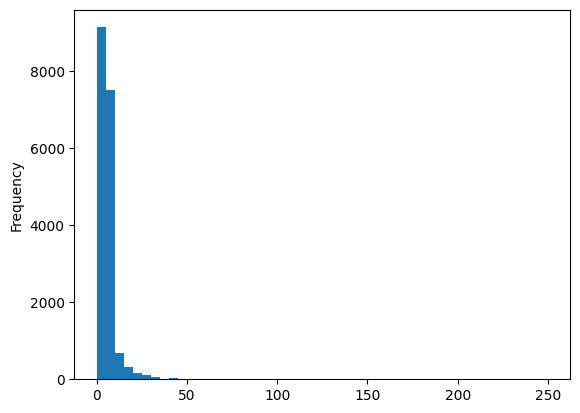

In [13]:
# 欠損処理
df["前面道路：幅員（ｍ）"].plot.hist(bins=50)

In [14]:
road = df["前面道路：幅員（ｍ）"].fillna(df["前面道路：幅員（ｍ）"].median())

In [15]:
road_cat = pd.cut(
    road,
    bins=[0, 5.5, np.inf],
    labels=["生活道路", "幹線道路"]
)

In [16]:
year = df["建築年"].str.extract(r"(?P<建築年>\d+)年").astype(float)

In [17]:
df["今後の利用目的"].value_counts()

,count
今後の利用目的,
住宅,8398
その他,915
事務所,225
店舗,212
倉庫,59
工場,29


In [18]:
df["取引の事情等"].value_counts()

,count
取引の事情等,
私道を含む取引,1366
隣地の購入,49
調停・競売等,41
関係者間取引,40
調停・競売等、私道を含む取引,7
隣地の購入、私道を含む取引,6
関係者間取引、私道を含む取引,3
私道を含む取引、その他事情有り,2
瑕疵有りの可能性,2


In [19]:
df["前面道路：種類"].value_counts()

,count
前面道路：種類,
公道,5316
私道,5015
区道,4612
市道,2331
都道,429
道路,372
国道,73
町道,47
区画街路,29


In [20]:
df["建物の構造"].value_counts()

,count
建物の構造,
木造,14967
鉄骨造,768
ＲＣ,731
軽量鉄骨造,606
ＳＲＣ,74
ＲＣ、木造,37
鉄骨造、木造,18
ブロック造,6
ＲＣ、鉄骨造,4


In [21]:
structure = df["建物の構造"]

In [22]:
remained = df.query("今後の利用目的 == '住宅'").dropna(subset="取引価格（㎡単価）")

## データセットの作成

In [23]:
y = remained["取引価格（㎡単価）"]
y.name = "price/area"

In [24]:
X = pd.concat(
    [from_station, city, road_cat],
    axis=1
).loc[y.index]
X.shape
X.columns = ["from_station", "city", "road"]

In [25]:
X.isnull().sum()

,0
from_station,0
city,0
road,0


In [26]:
X["from_station"].value_counts()

,count
from_station,
5〜9分,918
10〜19分,855
0〜4分,346
20〜29分,141
30分～60分,60
1H～1H30,9
1H30～2H,5
2H～,4


In [27]:
X["city"].value_counts()


,count
city,
世田谷区,202
大田区,185
杉並区,161
練馬区,125
八王子市,98
足立区,94
板橋区,91
品川区,88
町田市,83


In [28]:
X["road"].value_counts()


,count
road,
生活道路,1601
幹線道路,737


In [29]:
X = X.query("city != '離島'")
y = y.loc[X.index]

In [30]:
print(X.shape, y.shape)

(2337, 3) (2337,)


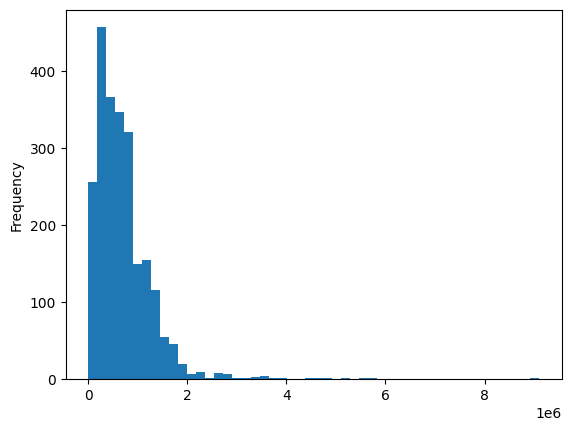

In [31]:
y.plot.hist(bins=50)
# plt.xscale("log")
plt.show()

## 線形回帰モデルの学習

In [33]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression


In [34]:
trans = OneHotEncoder(drop="first")
model = LinearRegression()
model.fit(trans.fit_transform(X), np.log10(y))

LinearRegression()

In [35]:
model.intercept_

np.float64(5.046309349567831)

In [36]:
model.coef_

array([-0.09558145, -0.87315622, -0.35808529, -0.19458538, -0.27910651,
       -0.33326085, -0.01343836,  0.83224867,  1.01224096,  1.38920253,
        0.98151634,  0.29793828,  0.87747574,  1.4889319 ,  1.18651234,
        1.05821486,  0.70698095,  0.66386979,  0.89562971,  0.39595096,
        0.88698861,  0.46941434,  0.76285963,  0.60695973,  1.21004821,
        1.15423477,  0.39137667,  0.43573585,  0.93465557,  0.56249783,
        0.39002434,  0.43130178,  0.82963587,  0.45900438,  0.92098428,
        0.69483148,  1.01409311,  0.52955883,  1.2850041 ,  1.40750508,
        0.63235195,  0.45959239,  1.12953657,  0.18013069,  0.46002593,
        0.5435553 ,  0.80250597,  0.19763534,  0.85823089,  0.68729033,
       -0.07318409,  0.61594414,  0.698693  ,  0.99975532,  0.62637392,
        0.08681555, -0.08711376])

In [37]:
trans.categories_

[array(['0〜4分', '10〜19分', '1H30～2H', '1H～1H30', '20〜29分', '2H～', '30分～60分',
        '5〜9分'], dtype=object),
 array(['あきる野市', '三鷹市', '世田谷区', '中央区', '中野区', '八王子市', '北区', '千代田区', '台東区',
        '品川区', '国分寺市', '国立市', '墨田区', '多摩市', '大田区', '小平市', '小金井市', '府中市',
        '文京区', '新宿区', '日野市', '昭島市', '杉並区', '東久留米市', '東大和市', '東村山市', '板橋区',
        '武蔵村山市', '武蔵野市', '江戸川区', '江東区', '清瀬市', '渋谷区', '港区', '狛江市', '町田市',
        '目黒区', '福生市', '稲城市', '立川市', '練馬区', '羽村市', '荒川区', '葛飾区', '西多摩郡',
        '西東京市', '調布市', '豊島区', '足立区', '青梅市'], dtype=object),
 array(['幹線道路', '生活道路'], dtype=object)]

In [38]:
trans.get_feature_names_out()

array(['from_station_10〜19分', 'from_station_1H30～2H',
       'from_station_1H～1H30', 'from_station_20〜29分', 'from_station_2H～',
       'from_station_30分～60分', 'from_station_5〜9分', 'city_三鷹市',
       'city_世田谷区', 'city_中央区', 'city_中野区', 'city_八王子市', 'city_北区',
       'city_千代田区', 'city_台東区', 'city_品川区', 'city_国分寺市', 'city_国立市',
       'city_墨田区', 'city_多摩市', 'city_大田区', 'city_小平市', 'city_小金井市',
       'city_府中市', 'city_文京区', 'city_新宿区', 'city_日野市', 'city_昭島市',
       'city_杉並区', 'city_東久留米市', 'city_東大和市', 'city_東村山市', 'city_板橋区',
       'city_武蔵村山市', 'city_武蔵野市', 'city_江戸川区', 'city_江東区', 'city_清瀬市',
       'city_渋谷区', 'city_港区', 'city_狛江市', 'city_町田市', 'city_目黒区',
       'city_福生市', 'city_稲城市', 'city_立川市', 'city_練馬区', 'city_羽村市',
       'city_荒川区', 'city_葛飾区', 'city_西多摩郡', 'city_西東京市', 'city_調布市',
       'city_豊島区', 'city_足立区', 'city_青梅市', 'road_生活道路'], dtype=object)

In [39]:
trans.drop_idx_

array([0, 0, 0], dtype=object)

In [40]:
list(map(lambda i_c:i_c[1][trans.drop_idx_[i_c[0]]], enumerate(trans.categories_)))

['0〜4分', 'あきる野市', '幹線道路']

In [41]:
pd.Series(model.coef_, index=trans.get_feature_names_out())

,0
from_station_10〜19分,-0.095581
from_station_1H30～2H,-0.873156
from_station_1H～1H30,-0.358085
from_station_20〜29分,-0.194585
from_station_2H～,-0.279107
from_station_30分～60分,-0.333261
from_station_5〜9分,-0.013438
city_三鷹市,0.832249
city_世田谷区,1.012241
city_中央区,1.389203


## モデルの保存と使用

In [42]:
import pickle

with open("models.pkl", "wb") as f:
    pickle.dump(
        {
            "trans":trans,
            "model":model
        },
        f
    )

In [43]:
import pickle

with open("models.pkl", "rb") as f:
    models = pickle.load(f)

trans = models["trans"]
model = models["model"]

In [44]:
record = {"from_station":"5〜9分",
          "city": "新宿区",
          "road": "生活道路"}
X_test = pd.DataFrame([record])
X_test

,from_station,city,road
0,5〜9分,新宿区,生活道路


In [45]:
10 ** model.predict(
    trans.transform(X_test)
)

array([1258902.23013401])

## アプリ開発に必要な情報の表示

In [46]:
import sklearn
sklearn.__version__

'1.6.1'

In [47]:
trans.feature_names_in_

array(['from_station', 'city', 'road'], dtype=object)

In [48]:
trans.categories_

[array(['0〜4分', '10〜19分', '1H30～2H', '1H～1H30', '20〜29分', '2H～', '30分～60分',
        '5〜9分'], dtype=object),
 array(['あきる野市', '三鷹市', '世田谷区', '中央区', '中野区', '八王子市', '北区', '千代田区', '台東区',
        '品川区', '国分寺市', '国立市', '墨田区', '多摩市', '大田区', '小平市', '小金井市', '府中市',
        '文京区', '新宿区', '日野市', '昭島市', '杉並区', '東久留米市', '東大和市', '東村山市', '板橋区',
        '武蔵村山市', '武蔵野市', '江戸川区', '江東区', '清瀬市', '渋谷区', '港区', '狛江市', '町田市',
        '目黒区', '福生市', '稲城市', '立川市', '練馬区', '羽村市', '荒川区', '葛飾区', '西多摩郡',
        '西東京市', '調布市', '豊島区', '足立区', '青梅市'], dtype=object),
 array(['幹線道路', '生活道路'], dtype=object)]